# SwipeWise — Part 4: Model Development
**Baselines:** DummyClassifier · Logistic Regression  
**Models:** Decision Tree · Random Forest · KNN

In [1]:
# ── STEP 1: Upload the 4 CSV files ──────────────────────────────────────────

from google.colab import files
uploaded = files.upload()

Saving target_encoder.joblib to target_encoder.joblib
Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


In [2]:
# ── STEP 2: Import all libraries we need ─────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt

# ── Baselines ──
from sklearn.dummy           import DummyClassifier
from sklearn.linear_model    import LogisticRegression

# ── Models ──
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier

# ── Evaluation metrics ──
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Libraries loaded!")

Libraries loaded!


In [4]:
# ── STEP 3: Load the data ────────────────────────────────────────────────────

X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test  = pd.read_csv("y_test.csv").values.ravel()


CLASS_NAMES = [
    "Blocked", "Catfished", "Chat Ignored", "Date Happened",
    "Ghosted", "Instant Match", "Mutual Match",
    "No Action", "One-sided Like", "Relationship Formed"
]

print("Training set :", X_train.shape)
print("Test set     :", X_test.shape)

Training set : (40000, 114)
Test set     : (10000, 114)


In [13]:
# ── STEP 4: Helper function ──────────────────────────────────────────────────


results = []   # we will collect every model's numbers here

def run_model(name, model):
    print(f"{'=' * 62}")
    print(f"  {name}")
    print(f"{'=' * 62}")


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)


    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score   (y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score       (y_test, y_pred, average="weighted", zero_division=0)


    print(f"  Accuracy  : {acc  * 100:.2f}%")
    print(f"  Precision : {prec * 100:.2f}%")
    print(f"  Recall    : {rec  * 100:.2f}%")
    print(f"  F1 Score  : {f1   * 100:.2f}%")

    #Print the detailed classification report
    print(f"--- Classification Report ---")
    print(classification_report(y_test, y_pred,
                                target_names=CLASS_NAMES,
                                zero_division=0))

    #Save numbers for the summary table at the end
    results.append({
        "Model"    : name,
        "Accuracy" : round(acc  * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall"   : round(rec  * 100, 2),
        "F1"       : round(f1   * 100, 2)
    })

print("Helper function ready!")

Helper function ready!


In [14]:
# ── BASELINE 1: DummyClassifier ──────────────────────────────────────────────


run_model(
    name  = "Baseline 1 — DummyClassifier",
    model = DummyClassifier(strategy="most_frequent", random_state=42)
)

  Baseline 1 — DummyClassifier
  Accuracy  : 10.22%
  Precision : 1.04%
  Recall    : 10.22%
  F1 Score  : 1.90%
--- Classification Report ---
                     precision    recall  f1-score   support

            Blocked       0.00      0.00      0.00      1010
          Catfished       0.00      0.00      0.00      1005
       Chat Ignored       0.00      0.00      0.00      1004
      Date Happened       0.00      0.00      0.00       984
            Ghosted       0.00      0.00      0.00       992
      Instant Match       0.00      0.00      0.00      1016
       Mutual Match       0.00      0.00      0.00       998
          No Action       0.00      0.00      0.00       997
     One-sided Like       0.10      1.00      0.19      1022
Relationship Formed       0.00      0.00      0.00       972

           accuracy                           0.10     10000
          macro avg       0.01      0.10      0.02     10000
       weighted avg       0.01      0.10      0.02     10000



In [15]:
# ── BASELINE 2: Logistic Regression ──────────────────────────────────────────


run_model(
    name  = "Baseline 2 — Logistic Regression",
    model = LogisticRegression(max_iter=1000, random_state=42)
)

  Baseline 2 — Logistic Regression
  Accuracy  : 10.28%
  Precision : 10.29%
  Recall    : 10.28%
  F1 Score  : 10.22%
--- Classification Report ---
                     precision    recall  f1-score   support

            Blocked       0.11      0.11      0.11      1010
          Catfished       0.11      0.11      0.11      1005
       Chat Ignored       0.10      0.11      0.11      1004
      Date Happened       0.10      0.10      0.10       984
            Ghosted       0.10      0.09      0.10       992
      Instant Match       0.10      0.10      0.10      1016
       Mutual Match       0.09      0.12      0.11       998
          No Action       0.10      0.08      0.09       997
     One-sided Like       0.11      0.13      0.12      1022
Relationship Formed       0.10      0.08      0.09       972

           accuracy                           0.10     10000
          macro avg       0.10      0.10      0.10     10000
       weighted avg       0.10      0.10      0.10     1

In [16]:
# ── MODEL 1: Decision Tree ───────────────────────────────────────────────────


run_model(
    name  = "Model 1 — Decision Tree",
    model = DecisionTreeClassifier(max_depth=10, random_state=42)
)

  Model 1 — Decision Tree
  Accuracy  : 9.64%
  Precision : 9.53%
  Recall    : 9.64%
  F1 Score  : 8.22%
--- Classification Report ---
                     precision    recall  f1-score   support

            Blocked       0.12      0.07      0.09      1010
          Catfished       0.10      0.11      0.11      1005
       Chat Ignored       0.10      0.09      0.09      1004
      Date Happened       0.09      0.23      0.13       984
            Ghosted       0.08      0.04      0.05       992
      Instant Match       0.09      0.04      0.06      1016
       Mutual Match       0.09      0.04      0.06       998
          No Action       0.10      0.02      0.03       997
     One-sided Like       0.10      0.27      0.14      1022
Relationship Formed       0.08      0.04      0.06       972

           accuracy                           0.10     10000
          macro avg       0.10      0.10      0.08     10000
       weighted avg       0.10      0.10      0.08     10000



In [17]:
# ── MODEL 2: Random Forest ───────────────────────────────────────────────────



run_model(
    name  = "Model 2 — Random Forest",
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
)

  Model 2 — Random Forest
  Accuracy  : 10.04%
  Precision : 9.96%
  Recall    : 10.04%
  F1 Score  : 9.94%
--- Classification Report ---
                     precision    recall  f1-score   support

            Blocked       0.12      0.15      0.13      1010
          Catfished       0.11      0.12      0.11      1005
       Chat Ignored       0.08      0.09      0.09      1004
      Date Happened       0.10      0.09      0.09       984
            Ghosted       0.10      0.09      0.10       992
      Instant Match       0.11      0.12      0.11      1016
       Mutual Match       0.09      0.09      0.09       998
          No Action       0.10      0.09      0.10       997
     One-sided Like       0.09      0.09      0.09      1022
Relationship Formed       0.09      0.06      0.08       972

           accuracy                           0.10     10000
          macro avg       0.10      0.10      0.10     10000
       weighted avg       0.10      0.10      0.10     10000



In [18]:
# ── MODEL 3: K-Nearest Neighbors (KNN) ───────────────────────────────────────


run_model(
    name  = "Model 3 — KNN",
    model = KNeighborsClassifier(n_neighbors=5)
)

  Model 3 — KNN
  Accuracy  : 10.03%
  Precision : 9.85%
  Recall    : 10.03%
  F1 Score  : 9.37%
--- Classification Report ---
                     precision    recall  f1-score   support

            Blocked       0.10      0.24      0.15      1010
          Catfished       0.10      0.16      0.12      1005
       Chat Ignored       0.11      0.13      0.12      1004
      Date Happened       0.10      0.09      0.10       984
            Ghosted       0.10      0.08      0.09       992
      Instant Match       0.09      0.06      0.07      1016
       Mutual Match       0.09      0.06      0.07       998
          No Action       0.11      0.07      0.09       997
     One-sided Like       0.09      0.06      0.07      1022
Relationship Formed       0.09      0.05      0.06       972

           accuracy                           0.10     10000
          macro avg       0.10      0.10      0.09     10000
       weighted avg       0.10      0.10      0.09     10000



In [19]:
# ── SUMMARY TABLE ────────────────────────────────────────────────────────────

summary = pd.DataFrame(results)
summary = summary.sort_values("F1", ascending=False).reset_index(drop=True)

print("" + "=" * 62)
print("  ALL MODELS — RANKED BY F1 SCORE")
print("=" * 62)
print(summary.to_string(index=False))

  ALL MODELS — RANKED BY F1 SCORE
                           Model  Accuracy  Precision  Recall    F1
Baseline 2 — Logistic Regression     10.28      10.29   10.28 10.22
         Model 2 — Random Forest     10.04       9.96   10.04  9.94
                   Model 3 — KNN     10.03       9.85   10.03  9.37
         Model 1 — Decision Tree      9.64       9.53    9.64  8.22
    Baseline 1 — DummyClassifier     10.22       1.04   10.22  1.90


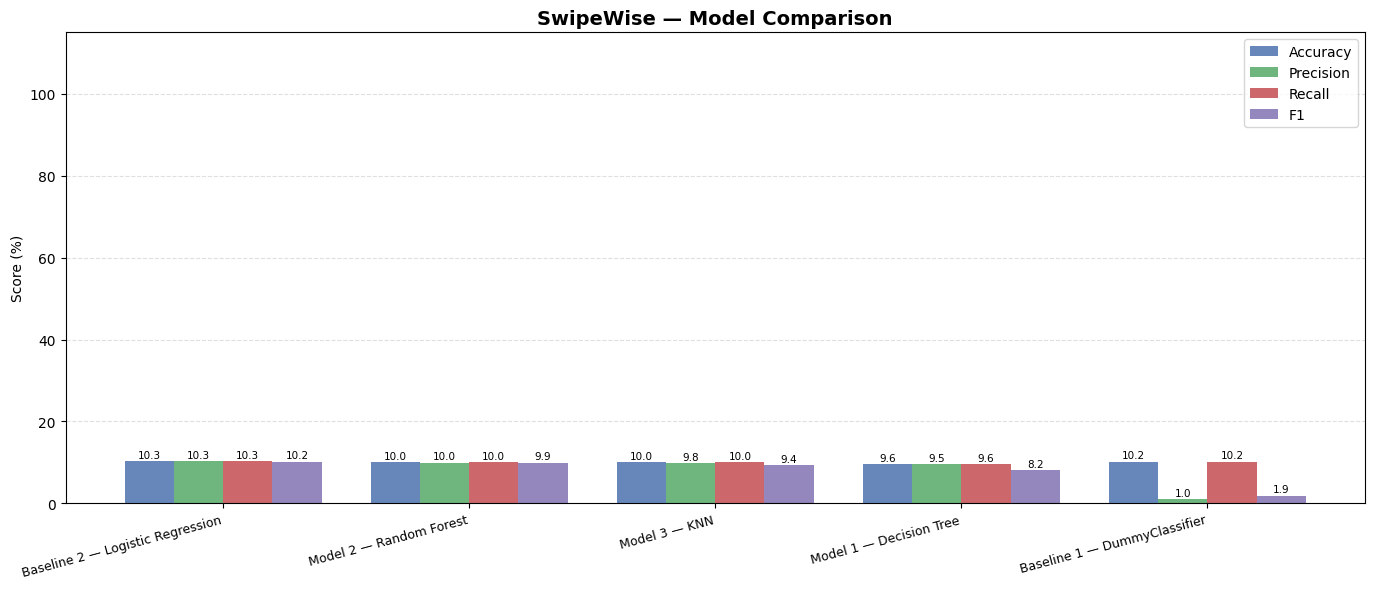

Chart saved as model_comparison.png


In [20]:
# ── COMPARISON CHART ─────────────────────────────────────────────────────────

metrics = ["Accuracy", "Precision", "Recall", "F1"]
x       = range(len(summary))
width   = 0.2
colors  = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(
        [xi + offset for xi in x],
        summary[metric],
        width  = width,
        label  = metric,
        color  = color,
        alpha  = 0.85
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=7.5
        )

ax.set_xticks(list(x))
ax.set_xticklabels(summary["Model"], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 115)
ax.set_title("SwipeWise — Model Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Chart saved as model_comparison.png")